# 2일차 2교시 실습 · 경계 검출

강의자료 PDF의 11~14쪽과 연결됩니다. 폴더 전체를 압축 해제하고 이 노트북을 엽니다. 위에서 아래로 실행하며 `____` 세 곳을 채웁니다. 필요한 패키지는 OpenCV, NumPy, Matplotlib입니다.

준비 코드는 완성되어 있습니다. `show_compare`와 `overlay`는 제공 함수입니다. 사진과 확대 구간은 강의자료 PDF와 동일합니다.


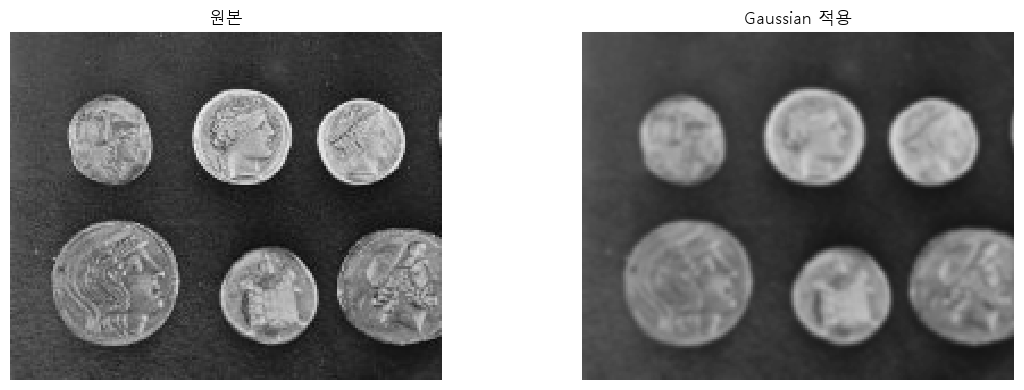

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
image_path = Path('images/coins.png')
assert image_path.is_file(), 'images/coins.png 위치를 확인하세요.'
gray = cv2.imdecode(np.fromfile(image_path, dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
assert gray is not None and gray.ndim == 2 and gray.dtype == np.uint8
prepared = cv2.GaussianBlur(gray, (5, 5), 1.0)
roi = (slice(150, 303), slice(0, 190))
zoom = (slice(162, 228), slice(10, 78))

def show_compare(images, titles, region=zoom):
    fig, axes = plt.subplots(1, len(images), figsize=(12, 4), squeeze=False)
    for ax, image, title in zip(axes[0], images, titles):
        ax.imshow(image[region], cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def overlay(image, edges):
    rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    rgb[edges > 0] = (25, 110, 255)
    return rgb

show_compare([gray, prepared], ['원본', 'Gaussian 적용'], region=roi)


## 방향별 미분값 확인 · 강의자료 PDF 6쪽
완성 코드입니다. Sobel은 x·y 방향의 밝기 미분값을 근사합니다. Gx·Gy는 부호를 가진 방향별 값이며, 화면에는 절댓값을 같은 척도로 표시합니다.


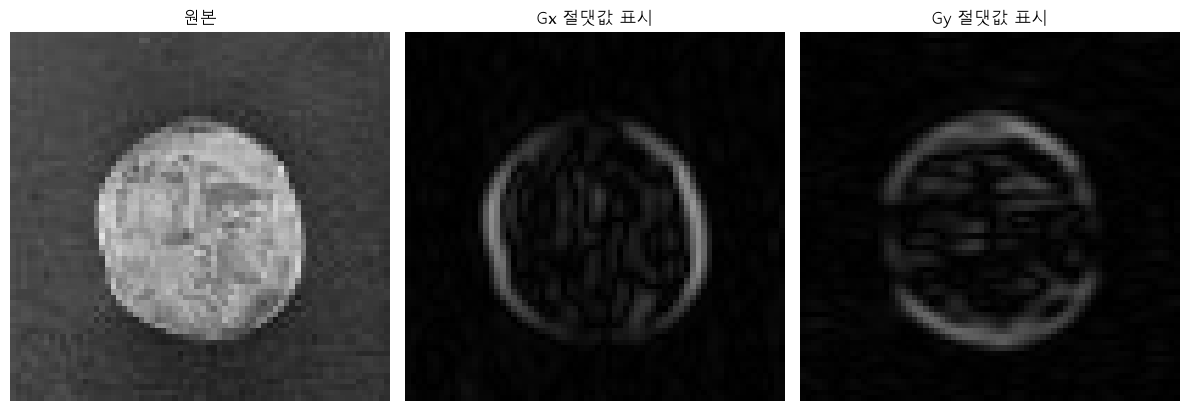

In [2]:
gx = cv2.Sobel(prepared, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(prepared, cv2.CV_32F, 0, 1, ksize=3)
gx_view = np.rint(np.clip(np.abs(gx) / 600 * 255, 0, 255)).astype(np.uint8)
gy_view = np.rint(np.clip(np.abs(gy) / 600 * 255, 0, 255)).astype(np.uint8)
show_compare([gray, gx_view, gy_view], ['원본', 'Gx 절댓값 표시', 'Gy 절댓값 표시'])


## Gradient 크기 · 강의자료 PDF 7쪽
Gx·Gy는 방향별 밝기 미분 근사값입니다. 이 예제의 Gradient 크기는 sqrt(Gx²+Gy²)로 계산합니다. Gx=3, Gy=4일 때 크기는5입니다. 이 숫자는 사진 측정값이 아닌 계산 예시입니다. Gradient 방향은 밝기가 가장 빠르게 증가하는 방향입니다.


## A · Canny 실행 · 강의자료 PDF 11쪽
함수 이름 한 곳을 채웁니다. `apertureSize=3`은 Sobel 커널 크기 3×3, `L2gradient=True`는 Gx·Gy로부터 Gradient 크기를 sqrt(Gx²+Gy²)로 계산하는 설정입니다. 두 옵션은 고정합니다.


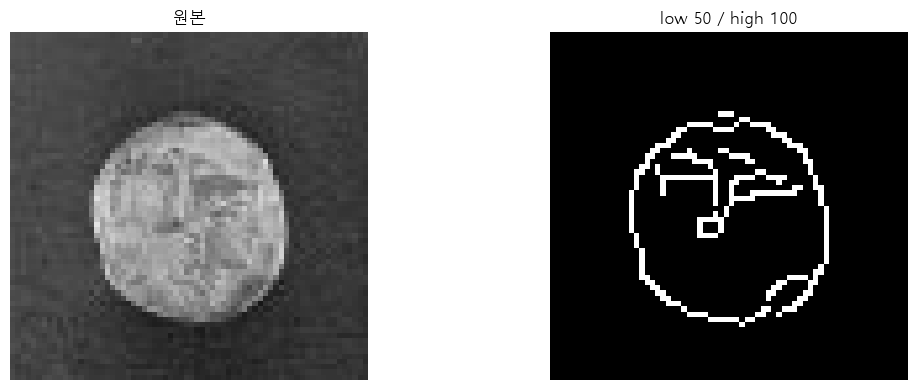

In [4]:
low, high = 50, 100
edges_base = cv2.Canny(prepared, low, high, apertureSize=3, L2gradient=True)
show_compare([gray, edges_base], ['원본', 'low 50 / high 100'])


## B · 하한 임계값만 변경 · 강의자료 PDF 12쪽
강의자료 PDF의 하한 임계값을 채웁니다. 상한 임계값 100을 유지합니다.


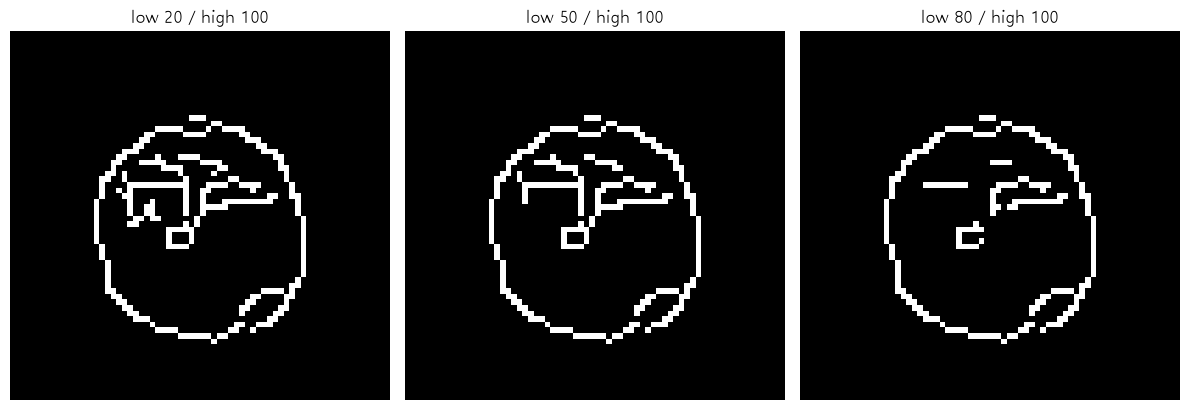

In [11]:
edges_low = cv2.Canny(prepared, 20, 100, apertureSize=3, L2gradient=True)
edges_low80 = cv2.Canny(prepared, 80, 100, apertureSize=3, L2gradient=True)
show_compare([edges_low, edges_base, edges_low80],
             ['low 20 / high 100', 'low 50 / high 100', 'low 80 / high 100'])


## C · 상한 임계값만 변경 · 강의자료 PDF 13쪽
강의자료 PDF의 상한 임계값을 채웁니다. 하한 임계값은 다시 50으로 지정합니다.


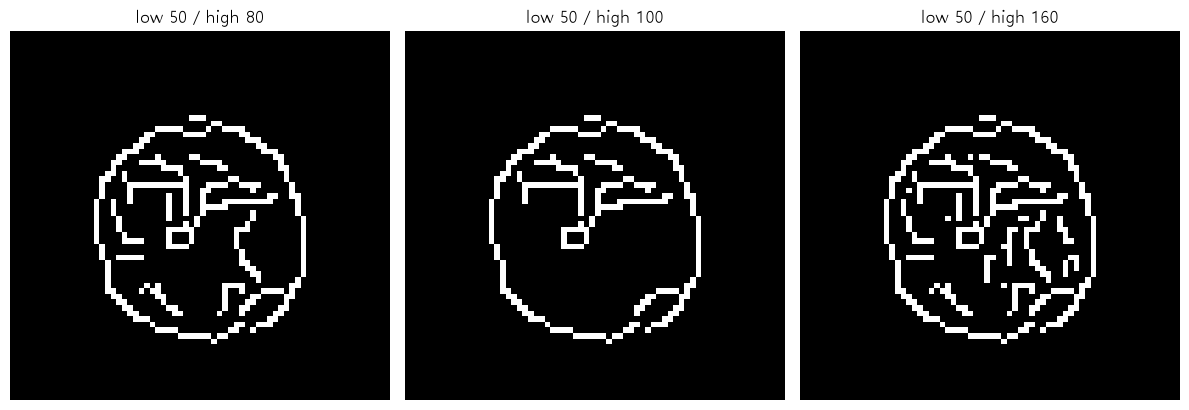

In [9]:
edges_high = cv2.Canny(prepared, 50, 50, apertureSize=3, L2gradient=True)
edges_high80 = cv2.Canny(prepared, 50, 80, apertureSize=3, L2gradient=True)
show_compare([edges_high80, edges_base, edges_high],
             ['low 50 / high 80', 'low 50 / high 100', 'low 50 / high 160'])


## 위치 비교와 저장 · 강의자료 PDF 14쪽
원본과 겹친 결과를 확인합니다. 저장 결과는 `results` 폴더에 생성됩니다.


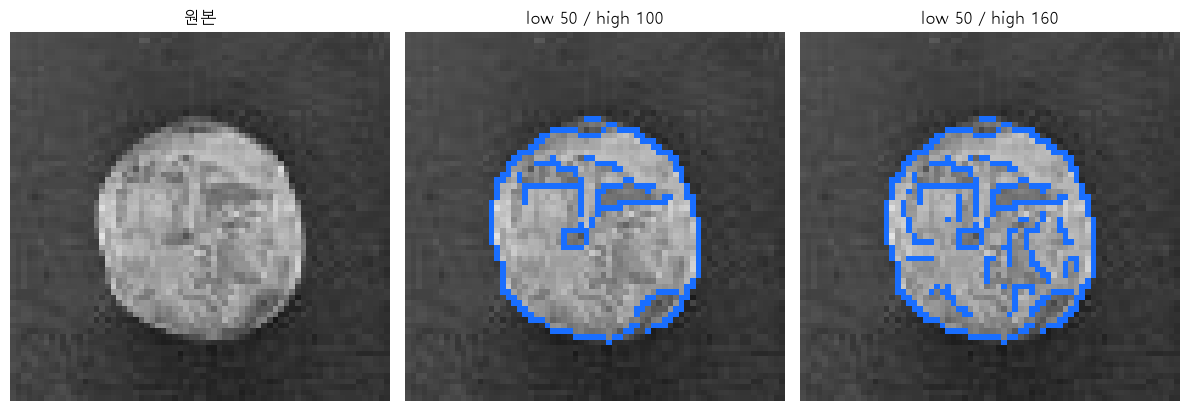

저장 위치: C:\Users\User\Downloads\Lecture_notes\13. 딥러닝 기반 영상처리_1,2일차\Pratice\day2\2교시\results


In [12]:
show_compare([gray, overlay(gray, edges_base), overlay(gray, edges_high)],
             ['원본', 'low 50 / high 100', 'low 50 / high 160'])
output_dir = Path('results')
output_dir.mkdir(exist_ok=True)
for name, result in [('edges_base', edges_base), ('edges_low', edges_low), ('edges_high', edges_high)]:
    ok, encoded = cv2.imencode('.png', result)
    assert ok
    encoded.tofile(output_dir / f'{name}.png')
print('저장 위치:', output_dir.resolve())


## 비교 · 강의자료 PDF 16쪽
원본의 대비를 낮춘 가공본입니다. 다른 조명에서 촬영한 사진이 아닙니다. 완성 코드로 제공하므로 실행한 뒤 결과를 비교합니다.


In [ ]:
reduced = np.rint(gray.astype(np.float32) * 0.5 + 64).clip(0, 255).astype(np.uint8)
reduced_prepared = cv2.GaussianBlur(reduced, (5, 5), 1.0)
reduced_edges = cv2.Canny(reduced_prepared, 50, 100, apertureSize=3, L2gradient=True)
reduced_adjusted = cv2.Canny(reduced_prepared, 25, 50, apertureSize=3, L2gradient=True)
show_compare([gray, reduced], ['원본', '대비를 낮춘 가공본'])
show_compare([edges_base, reduced_edges, reduced_adjusted],
             ['원본 50 / 100', '가공본 50 / 100', '가공본 25 / 50'])
